# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score,precision_score, ConfusionMatrixDisplay

# TIP: Asegúrense de importar aquí los tres clasificadores de scikit-learn que elijan probar,
# junto con las métricas de evaluación (accuracy_score, confusion_matrix, etc.)

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [2]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle
df = pd.read_csv("Train.csv")
# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### Columnas del Dataset

- ID: Número de identificación del cliente.
- Warehouse_block: La empresa tiene un gran almacén que está dividido en bloques como A, B, C, D, E.
- Mode_of_Shipment: La empresa envía los productos de diversas maneras, como por barco, avión y carretera.
- Customer_care_calls: Número de llamadas realizadas para consultas sobre el envío.
- Customer_rating: La empresa ha recibido valoraciones de todos sus clientes. 1 es la peor valoración y 5 la mejor.
- Cost_of_the_Product: Costo del producto en dólares estadounidenses.
- Prior_purchases: El número de compras anteriores.
- Product_importance: La empresa ha categorizado el producto en varios parámetros como bajo, medio, alto.
- Gender: Masculino y Femenino.
- Discount_offered: Descuento ofrecido en ese producto específico.
- Weight_in_gms: Es el peso en gramos.

- Reached.on.Time_Y.N: Es la variable objetivo, donde 1 indica que el producto NO se ha entregado a tiempo y 0 indica que se ha entregado a tiempo.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [4]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [5]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


La validacion del dataset nos muestra un total de 10999 filas y 12 columnas.

Ninguna de estas tiene datos faltantes ya que indica non-null para todas las columnas

Para el ejercicio debemos hacer limpieza de 4 columnas que estan con Dtype = str (solo es posible Machine Learning con variables numericas)

## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [6]:
#Paso 2: Identificación y transformación de variables categóricas

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

df["Product_importance"].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

In [7]:
df["Product_importance"] = (df["Product_importance"].map({"low": 0, "medium": 1, "high": 2}).astype(int))
df["Product_importance"].value_counts()

Product_importance
0    5297
1    4754
2     948
Name: count, dtype: int64

In [8]:
df["Gender"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [9]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Gender"].value_counts()

Gender
0    5545
1    5454
Name: count, dtype: int64

In [10]:
# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).
df["Warehouse_block"].unique()

<StringArray>
['D', 'F', 'A', 'B', 'C']
Length: 5, dtype: str

In [11]:
encoder = OneHotEncoder(sparse_output=False)
warehouse_encoded = encoder.fit_transform(df[["Warehouse_block"]])

In [12]:
warehouse_encoded[:5]

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [13]:
warehouse_encoded = pd.DataFrame(warehouse_encoded,columns=encoder.get_feature_names_out(["Warehouse_block"]))
warehouse_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Warehouse_block_A  10999 non-null  float64
 1   Warehouse_block_B  10999 non-null  float64
 2   Warehouse_block_C  10999 non-null  float64
 3   Warehouse_block_D  10999 non-null  float64
 4   Warehouse_block_F  10999 non-null  float64
dtypes: float64(5)
memory usage: 429.8 KB


In [14]:
df = df.drop("Warehouse_block", axis =1)
df = pd.concat([df, warehouse_encoded], axis=1)

In [15]:
df = df.drop("ID", axis=1)

In [16]:
df["Mode_of_Shipment"].unique()

<StringArray>
['Flight', 'Ship', 'Road']
Length: 3, dtype: str

In [17]:
df = pd.get_dummies(df,columns=["Mode_of_Shipment"])
df[["Mode_of_Shipment_Flight", "Mode_of_Shipment_Road", "Mode_of_Shipment_Ship"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Mode_of_Shipment_Flight  10999 non-null  bool 
 1   Mode_of_Shipment_Road    10999 non-null  bool 
 2   Mode_of_Shipment_Ship    10999 non-null  bool 
dtypes: bool(3)
memory usage: 32.4 KB


In [18]:
cols_mode = df.filter(like="Mode_of_Shipment").columns

df[cols_mode] = df[cols_mode].astype(int)

In [19]:
df.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
0,4,2,177,3,0,0,44,1233,1,0.0,0.0,0.0,1.0,0.0,1,0,0
1,4,5,216,2,0,1,59,3088,1,0.0,0.0,0.0,0.0,1.0,1,0,0
2,2,2,183,4,0,1,48,3374,1,1.0,0.0,0.0,0.0,0.0,1,0,0
3,3,3,176,4,1,1,10,1177,1,0.0,1.0,0.0,0.0,0.0,1,0,0
4,2,2,184,3,1,0,46,2484,1,0.0,0.0,1.0,0.0,0.0,1,0,0


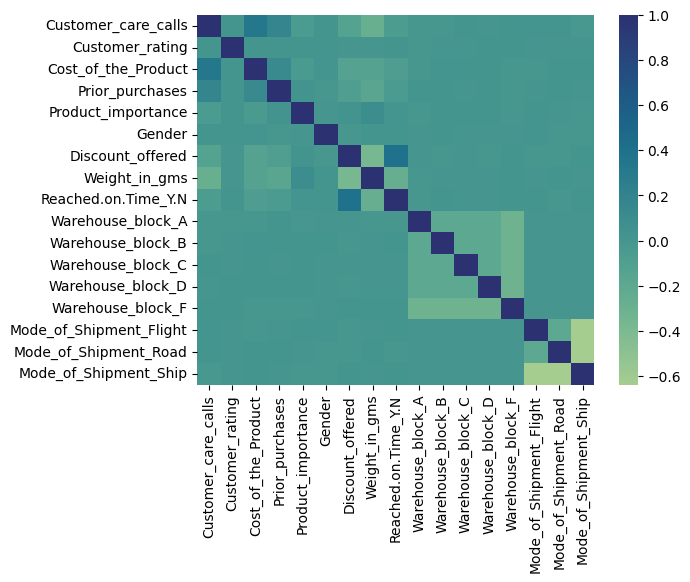

In [20]:
mc = sns.heatmap(df.corr(), cmap = 'crest')

In [21]:
# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

In [22]:
print("Distribución de la variable objetivo")
print (df['Reached.on.Time_Y.N'].value_counts())

Distribución de la variable objetivo
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


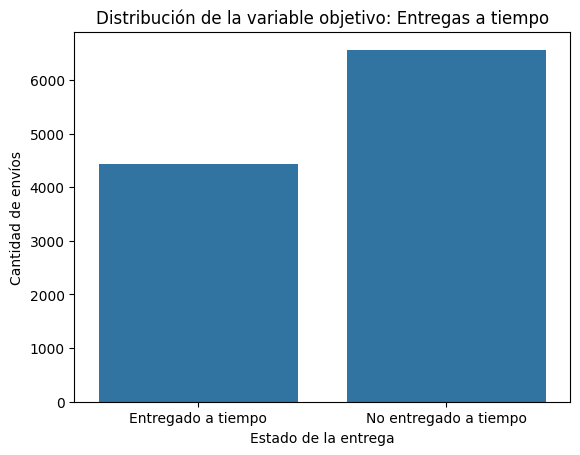

In [23]:
sns.countplot(x='Reached.on.Time_Y.N', data=df)

plt.title('Distribución de la variable objetivo: Entregas a tiempo')
plt.xticks([0, 1], ["Entregado a tiempo", "No entregado a tiempo"])
plt.xlabel("Estado de la entrega")
plt.ylabel("Cantidad de envíos")
plt.show()

## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [24]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables

X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)


In [25]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(9899, 16) (1100, 16)
(9899,) (1100,)


## 4. Entrenamiento de Modelos

Paso 4: Entrenamiento y evaluación de modelos

Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

### Random Forest Classifier

In [26]:
# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
y_pred_rf = modelo_rf.predict(X_test)

### Decision Tree Classifier

In [28]:
# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
y_pred_dt = modelo_dt.predict(X_test)

### KNeighbors Classifier

In [30]:
# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [31]:
y_pred_knn = modelo_knn.predict(X_test)

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

In [32]:
print("Reporte de clasificación Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación Random Forest
              precision    recall  f1-score   support

           0       0.56      0.72      0.63       444
           1       0.77      0.62      0.69       656

    accuracy                           0.66      1100
   macro avg       0.67      0.67      0.66      1100
weighted avg       0.68      0.66      0.66      1100



In [33]:
print("Reporte de clasificación Decision Tree")
print(classification_report(y_test, y_pred_dt))

Reporte de clasificación Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       444
           1       0.70      0.70      0.70       656

    accuracy                           0.64      1100
   macro avg       0.63      0.63      0.63      1100
weighted avg       0.64      0.64      0.64      1100



In [34]:
print("Reporte de clasificación KNN")
print(classification_report(y_test, y_pred_knn))

Reporte de clasificación KNN
              precision    recall  f1-score   support

           0       0.55      0.60      0.57       444
           1       0.71      0.67      0.69       656

    accuracy                           0.64      1100
   macro avg       0.63      0.63      0.63      1100
weighted avg       0.65      0.64      0.64      1100



In [35]:
resultados = {
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "KNN": accuracy_score(y_test, y_pred_knn),
}
print(resultados)

{'Random Forest': 0.6618181818181819, 'Decision Tree': 0.6418181818181818, 'KNN': 0.64}


In [36]:
df_resultados = pd.DataFrame(list(resultados.items()),columns=["Modelo", "Accuracy"])

print(df_resultados)

          Modelo  Accuracy
0  Random Forest  0.661818
1  Decision Tree  0.641818
2            KNN  0.640000


In [37]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

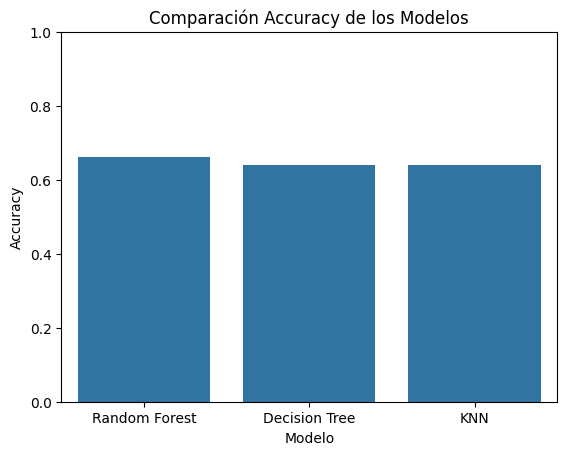

In [38]:
sns.barplot(data=df_resultados,x="Modelo",y="Accuracy")

plt.title("Comparación Accuracy de los Modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [39]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

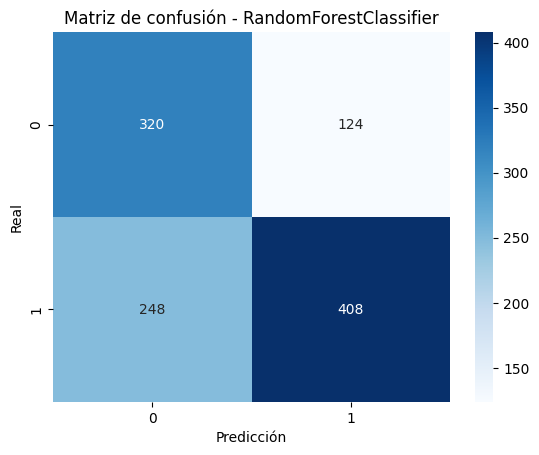

In [40]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de confusión - RandomForestClassifier')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

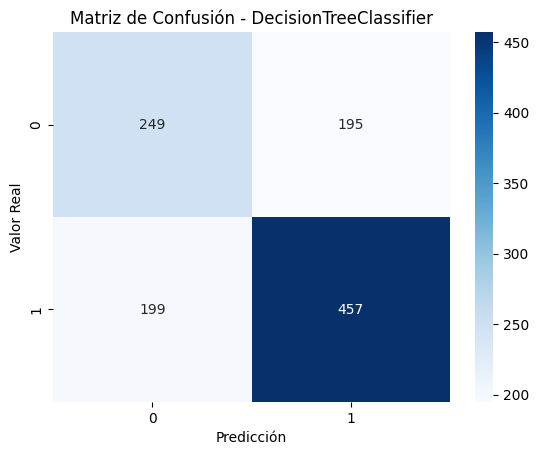

In [41]:
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - DecisionTreeClassifier")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

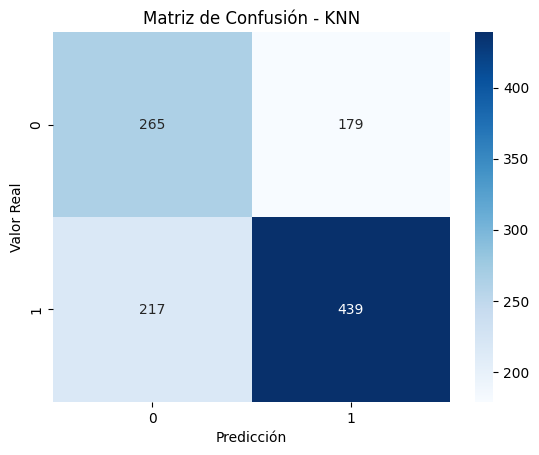

In [42]:
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

### Conclusión tras la evaluacion de los tres modelos de clasificacion

- Random Forest
- Decision Tree 
- KNN utilizando 

De acuerdo al analisis de las matrices de confusion podria concluir que el mejor modelo en este ejercicio fue:

Random Forest accuracy 66%, los otros dos modelos accuracy 64%
